# Data preparation notebook
---
This notebook is part of a multi-notebook project analyzing population changes and demographic patterns in Aruba from 2015 to 2023.

It focuses on preparing a clean, structured baseline dataset and building a reusable data pipeline for downstream analysis.

Workflow: Raw Excel → Cleaned long dataset (tidy) → Processed CSV → SQLite
---

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Establish path
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

from config.project_paths import (
    ROOT,
    DATA_RAW,
    DATA_PROCESSED
)

In [2]:
# Verify all paths
print("ROOT:", ROOT)
print("RAW DATA:", DATA_RAW)
print("PROCESSED DATA:", DATA_PROCESSED)

ROOT: /home/ggirelli/Documents/DataAnalysis/projects/cbs_aruba
RAW DATA: /home/ggirelli/Documents/DataAnalysis/projects/cbs_aruba/data/raw
PROCESSED DATA: /home/ggirelli/Documents/DataAnalysis/projects/cbs_aruba/data/processed


In [3]:
# Load raw data
RAW_DEMOGRAPHIC_ASPECTS_FILE = DATA_RAW / "Demographic-aspects-2023.xlsx"

In [4]:
# Create "if statement" to test for errors
if not RAW_DEMOGRAPHIC_ASPECTS_FILE.exists():
    raise FileNotFoundError

In [5]:
# Set variable for wide format
population_raw = pd.read_excel(RAW_DEMOGRAPHIC_ASPECTS_FILE, header=1)

In [6]:
# Filter to keep main columns for further analysis 
population_filtered = population_raw[
population_raw["Key Demographic aspects"].isin(["Males", "Females"])]

population_filtered

,Key Demographic aspects,Unit,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Males,Absolute,51309.0,51462.0,51399.0,51512.0,51515.0,50930.0,50664.0,50440.0,50559.0
1,Females,Absolute,57326.0,57357.0,57253.0,57652.0,57726.0,57002.0,56804.0,56712.0,57007.0


In [7]:
# Filter out unneeded column 'Unit'
population_filtered = population_filtered.drop(columns=["Unit"])

In [8]:
population_filtered

,Key Demographic aspects,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Males,51309.0,51462.0,51399.0,51512.0,51515.0,50930.0,50664.0,50440.0,50559.0
1,Females,57326.0,57357.0,57253.0,57652.0,57726.0,57002.0,56804.0,56712.0,57007.0


In [9]:
# Use .melt() to convert wide format (years as columns) to long format (tidy data)
final_df = population_filtered.melt(
    id_vars = ["Key Demographic aspects"],
    var_name = "year",
    value_name = "population"
)

final_df.head(3)

,Key Demographic aspects,year,population
0,Males,2015,51309.0
1,Females,2015,57326.0
2,Males,2016,51462.0


In [10]:
final_df = final_df.rename(columns={"Key Demographic aspects" : "sex"})

In [11]:
final_df["year"] = pd.to_numeric(final_df["year"], errors="coerce")

In [12]:
final_df.head()

final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sex         18 non-null     str    
 1   year        18 non-null     int64  
 2   population  18 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 681.0 bytes


In [13]:
final_df = final_df.sort_values(["sex", "year"]).reset_index(drop=True)

final_df["annual_change"] = final_df.groupby("sex")["population"].diff()

# Final output (result)
final_df

,sex,year,population,annual_change
0,Females,2015,57326.0,NaN
1,Females,2016,57357.0,31.0
2,Females,2017,57253.0,-104.0
3,Females,2018,57652.0,399.0
4,Females,2019,57726.0,74.0
5,Females,2020,57002.0,-724.0
6,Females,2021,56804.0,-198.0
7,Females,2022,56712.0,-92.0
8,Females,2023,57007.0,295.0
9,Males,2015,51309.0,NaN


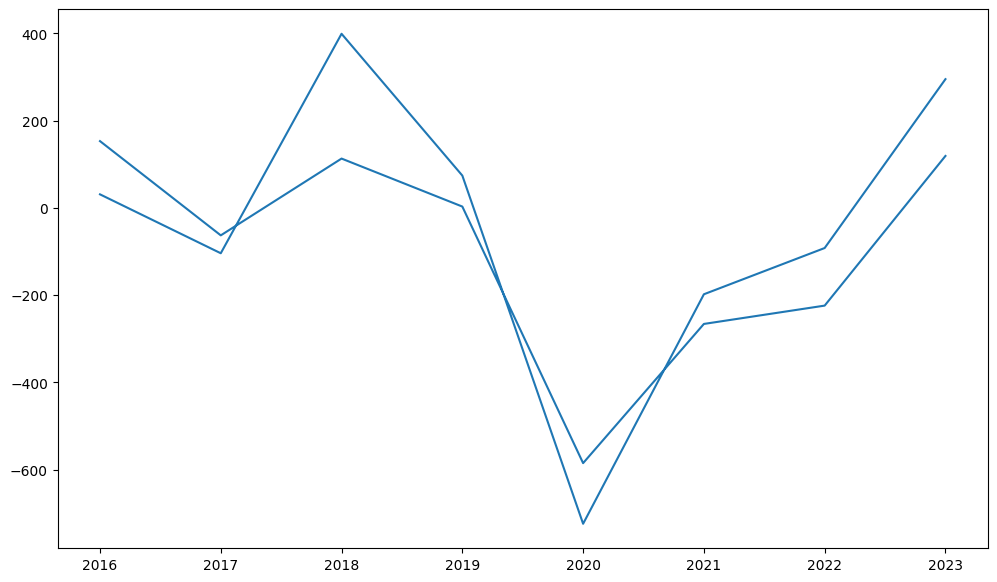

In [20]:
plt.figure(figsize=(12, 7))

plt.plot(final_df["year"], final_df["annual_change"])

plt.show()

In [14]:
# Write to file
output_file = DATA_PROCESSED / "population_change_by_sex.csv"
final_df.to_csv(output_file, index=False)

---
**The dataset is now cleaned, structured, and ready for downstream analysis in SQLite and notebooks.**